### Tasks

* 1. Create a Python script that generates two arrays: one representing the number of hours you spend on Instagram each day for a week, and the other representing your daily phone battery percentage at the end of the day. Plot these as a scatter plot using matplotlib.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
instagram_hours = np.array([2, 3, 1.5, 4, 2.5, 5, 3.5])
battery_percentage = np.array([60, 50, 75, 35, 55, 20, 40])

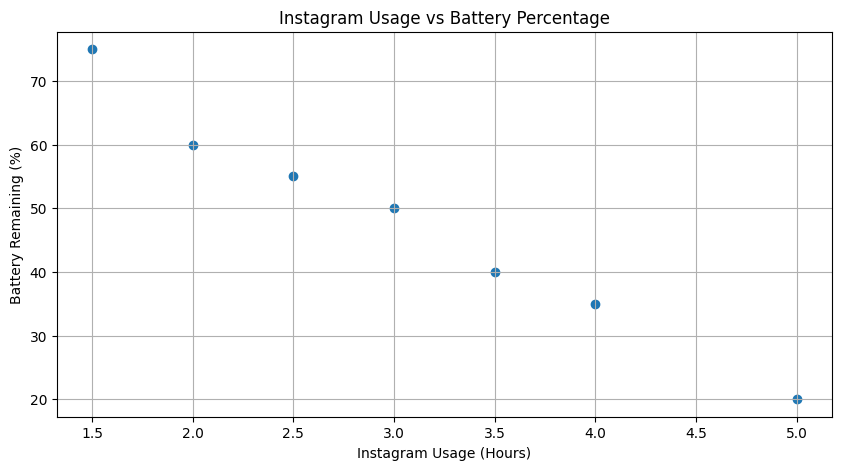

In [33]:
plt.figure(figsize=(10,5))
plt.scatter(instagram_hours, battery_percentage)

plt.title("Instagram Usage vs Battery Percentage")
plt.xlabel("Instagram Usage (Hours)")
plt.ylabel("Battery Remaining (%)")

plt.grid()
plt.show()

* 2. Using scikit-learn's LinearRegression, fit a simple linear regression model to predict daily battery percentage based on Instagram usage hours from your generated data. Print the model's slope (coefficient) and intercept.

In [34]:
df = pd.DataFrame({
    'instagram_hours': instagram_hours,
    'battery_percentage': battery_percentage
})

In [52]:
df

,instagram_hours,battery_percentage
0,2.0,60
1,3.0,50
2,1.5,75
3,4.0,35
4,2.5,55
5,5.0,20
6,3.5,40


### Split: X, y

In [35]:
X = df[['instagram_hours']]
y = df['battery_percentage']

### Train, Test, Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### LinearRegression

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [38]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)

### Accuracy

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [42]:
print(f"MSE: {mse}\nMAE: {mae}\nR² Score: {r2}")

MSE: 12.742775379996312
MAE: 2.7054794520547993
R² Score: 0.4902889848001475


* 3. Plot the regression line on top of your scatter plot to visualize the relationship between Instagram hours and battery percentage using matplotlib.<br><br><em><strong>Hint:</strong> Use model.predict() to get the predicted values for your x-axis data and plot them as a line.</em>

In [54]:
y_pred_graph = model.predict(X)
y_pred_graph

array([65.03424658, 49.62328767, 72.73972603, 34.21232877, 57.32876712,
       18.80136986, 41.91780822])

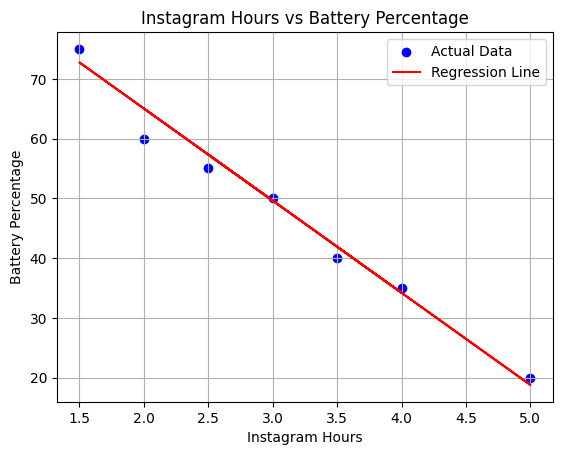

In [51]:
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, y_pred_graph, color='red', label="Regression Line")

plt.title("Instagram Hours vs Battery Percentage")
plt.xlabel("Instagram Hours")
plt.ylabel("Battery Percentage")
plt.legend()
plt.grid()

plt.show()

* 4. Calculate the mean squared error (MSE) between your actual battery percentages and the predicted values from your regression model using sklearn.metrics.mean_squared_error. Print the MSE value and explain in one line what a lower MSE indicates.

In [47]:
mse = mean_squared_error(y_test, y_pred)

In [49]:
print("MSE:", mse)

MSE: 12.742775379996312


A lower MSE indicates that the model's predicted battery percentages are closer to the actual battery percentages, meaning the model is more accurate.